# 简化版行为分布可视化

使用方法：
1. 在下方代码开头修改 `DATA_DIR`；
2. 在 `INDIVIDUAL_FILES` 中保留需要展示的个体；
3. 运行代码单元。

In [1]:
from pathlib import Path
from collections import Counter
import math
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 第1步：只修改这里
# ============================================================

# 数据所在文件夹：该文件夹中应包含 label_all2.csv 和各个体原始CSV
DATA_DIR = Path(
    r"D:\dl-wabc\data\datasets\raw-data\omizunagidori"
)

# 整体数据文件
OVERALL_FILE = DATA_DIR / "label_all2.csv"

# 第2步：选择需要展示的个体
# 想展示几个个体，就保留几行；可以只放1个，也可以放多个
INDIVIDUAL_FILES = {
    "OM1803": DATA_DIR / "Omizunagidori2018_raw_data_9B34075_lb0003.csv",
    "OM1804": DATA_DIR / "Omizunagidori2018_raw_data_9B36347_lb0004.csv",
    "OM1805": DATA_DIR / "Omizunagidori2018_raw_data_9B36360_lb0005.csv",
}

# 结果自动保存到该文件夹，不需要提前创建
OUTPUT_DIR = DATA_DIR / "visualization_results"

# 滑动窗口参数：采样率为25 Hz时，50个点=2秒，步长25个点=1秒
WINDOW_SIZE = 50
STRIDE = 25


# 将行为类别统一起来
CLASSES = [
    "stationary",
    "bathing",
    "flight_take_off",
    "flight_cruising",
    "foraging_dive",
    "body_shaking",
    "surface_seizing",
    "preening",
    "dipping",
]

# 图中显示的名称
DISPLAY_NAMES = {
    "stationary": "Stationary",
    "bathing": "Bathing",
    "flight_take_off": "Take-off",
    "flight_cruising": "Cruising flight",
    "foraging_dive": "Foraging dive",
    "body_shaking": "Body shaking",
    "surface_seizing": "Surface seizing",
    "preening": "Preening",
    "dipping": "Dipping",
}

# 统一不同文件中的标签写法
LABEL_MAP = {
    "stationary": "stationary",
    "bathing": "bathing",

    "flight_take_off": "flight_take_off",
    "flight take off": "flight_take_off",
    "take-off": "flight_take_off",
    "takeoff": "flight_take_off",
    "take off": "flight_take_off",

    "flight_cruising": "flight_cruising",
    "flight cruising": "flight_cruising",
    "cruising flight": "flight_cruising",

    "foraging_dive": "foraging_dive",
    "foraging dive": "foraging_dive",

    "body_shaking": "body_shaking",
    "body shaking": "body_shaking",

    "surface_seizing": "surface_seizing",
    "surface seizing": "surface_seizing",

    "preening": "preening",
    "dipping": "dipping",
}


1/2 正在生成整体行为分布图……


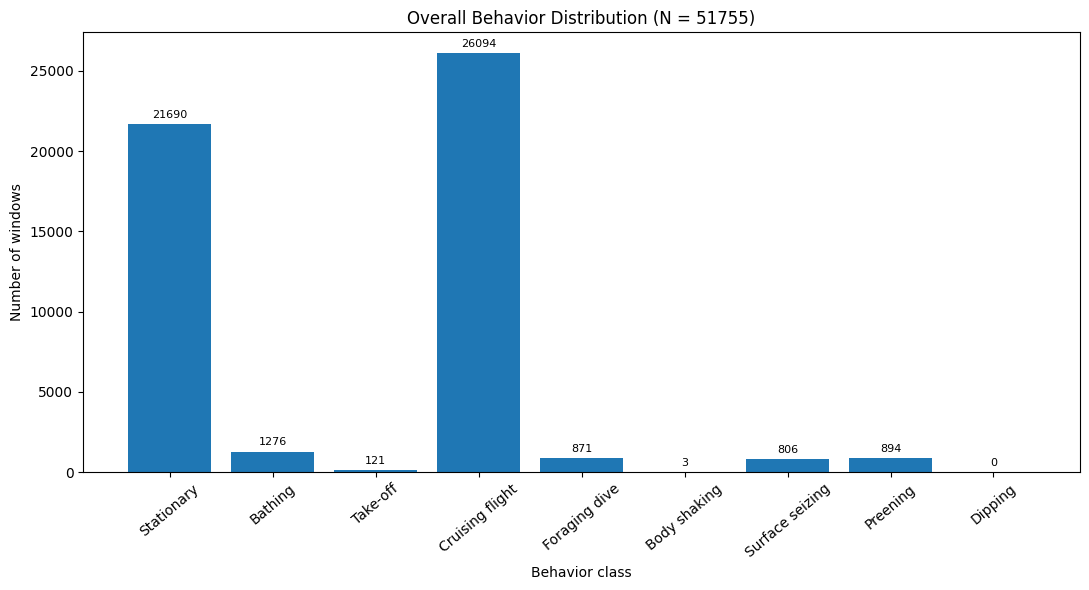

2/2 正在生成所选个体行为分布图……
  正在处理：OM1803
  正在处理：OM1804
  正在处理：OM1805


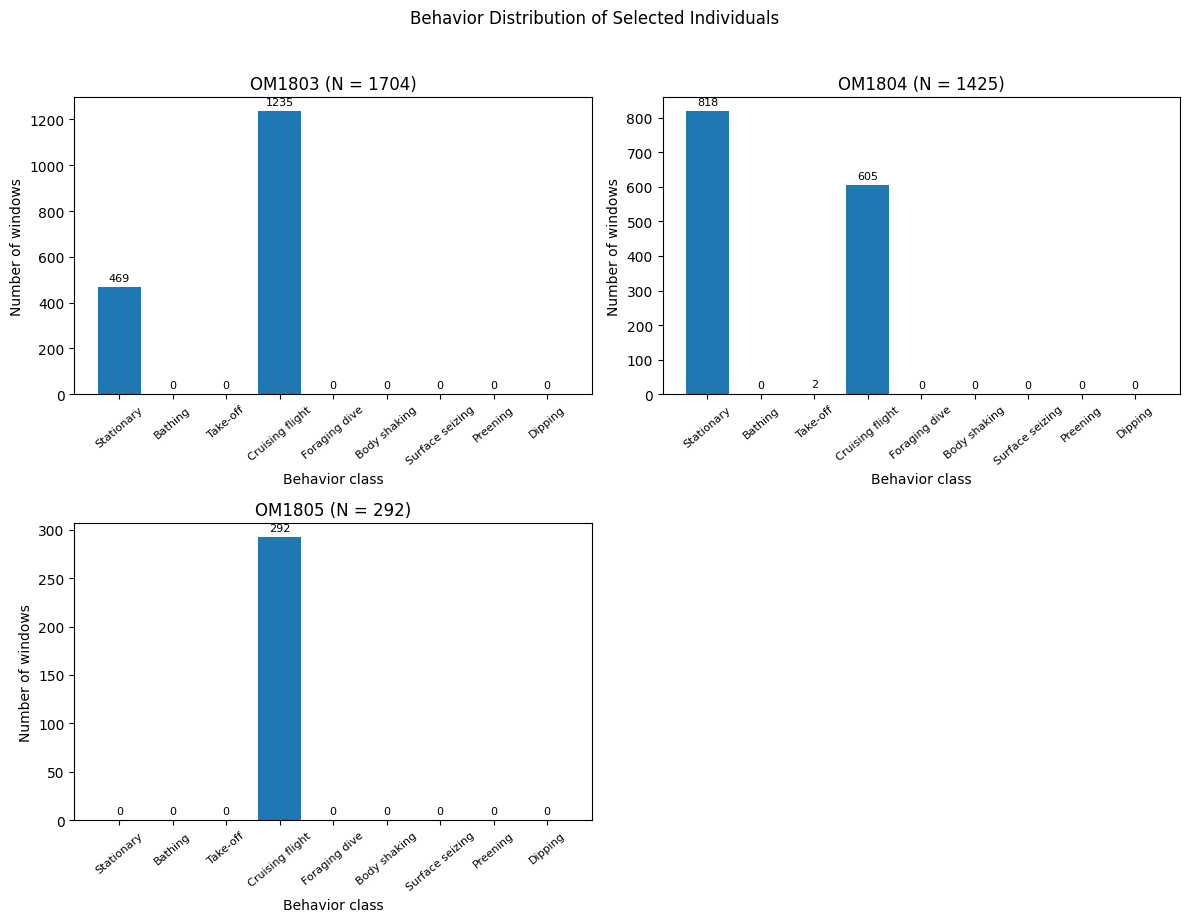


处理完成，结果保存在：
D:\dl-wabc\data\datasets\raw-data\omizunagidori\visualization_results

生成的文件：
1. overall_behavior_distribution.png：整体柱状图
2. selected_individual_behavior_distribution.png：个体柱状图
3. overall_behavior_counts.csv：整体统计表
4. selected_individual_behavior_counts.csv：个体统计表


In [2]:
def read_csv_safely(path):
    """读取CSV；默认编码失败时自动尝试GBK。"""
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"找不到文件：{path}")

    try:
        return pd.read_csv(path, low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="gbk", low_memory=False)


def standardize_labels(df):
    """清理并统一label列。"""
    if "label" not in df.columns:
        raise KeyError("CSV中没有找到 label 列，请检查文件是否选对。")

    labels = (
        df["label"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    # 将无效标签变为缺失值
    labels = labels.replace({
        "": pd.NA,
        "nan": pd.NA,
        "none": pd.NA,
        "unknown": pd.NA,
    })

    return labels.map(LABEL_MAP)


def count_pure_windows(path):
    """
    按照窗口大小50、步长25提取窗口。
    只有窗口内50个点都有标签且标签完全一致时，才计为一个有效窗口。
    """
    df = read_csv_safely(path)
    labels = standardize_labels(df)

    counts = Counter()

    for start in range(0, len(labels) - WINDOW_SIZE + 1, STRIDE):
        window = labels.iloc[start:start + WINDOW_SIZE]

        # 50个点必须都有有效标签，并且全部属于同一行为
        if window.notna().all() and window.nunique() == 1:
            counts[window.iloc[0]] += 1

    return pd.Series(
        {behavior: counts.get(behavior, 0) for behavior in CLASSES},
        dtype="int64",
    )


def add_value_labels(ax, bars):
    """在每根柱子上方显示数量。"""
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            str(int(height)),
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )


def plot_overall(counts, save_path):
    """绘制整体行为分布柱状图。"""
    labels = [DISPLAY_NAMES[c] for c in CLASSES]
    values = counts.reindex(CLASSES).fillna(0).astype(int).tolist()

    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.bar(labels, values)
    add_value_labels(ax, bars)

    ax.set_title(f"Overall Behavior Distribution (N = {sum(values)})")
    ax.set_xlabel("Behavior class")
    ax.set_ylabel("Number of windows")
    ax.tick_params(axis="x", rotation=40)

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_individuals(results, save_path):
    """绘制所选个体的行为分布子图。"""
    number_of_individuals = len(results)

    if number_of_individuals == 0:
        print("没有设置个体文件，跳过个体图。")
        return

    columns = 2 if number_of_individuals > 1 else 1
    rows = math.ceil(number_of_individuals / columns)

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(columns * 6, rows * 4.5),
        squeeze=False,
    )
    axes = axes.flatten()
    labels = [DISPLAY_NAMES[c] for c in CLASSES]

    for ax, (individual, row) in zip(axes, results.iterrows()):
        values = row.reindex(CLASSES).fillna(0).astype(int).tolist()
        bars = ax.bar(labels, values)
        add_value_labels(ax, bars)

        ax.set_title(f"{individual} (N = {sum(values)})")
        ax.set_xlabel("Behavior class")
        ax.set_ylabel("Number of windows")
        ax.tick_params(axis="x", rotation=40, labelsize=8)

    # 删除空白子图
    for ax in axes[number_of_individuals:]:
        fig.delaxes(ax)

    fig.suptitle(
        "Behavior Distribution of Selected Individuals",
        y=1.02,
    )
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # 1. 整体可视化：读取代码2生成的label_all2.csv
    print("1/2 正在生成整体行为分布图……")
    overall_counts = count_pure_windows(OVERALL_FILE)

    overall_table = overall_counts.rename("count").to_frame()
    overall_table.index.name = "behavior"
    overall_table.to_csv(
        OUTPUT_DIR / "overall_behavior_counts.csv",
        encoding="utf-8-sig",
    )

    plot_overall(
        overall_counts,
        OUTPUT_DIR / "overall_behavior_distribution.png",
    )

    # 2. 个体可视化：读取上方指定的若干个体CSV
    print("2/2 正在生成所选个体行为分布图……")
    individual_results = {}

    for individual, path in INDIVIDUAL_FILES.items():
        print(f"  正在处理：{individual}")
        individual_results[individual] = count_pure_windows(path)

    individual_table = (
        pd.DataFrame(individual_results)
        .T
        .reindex(columns=CLASSES)
        .fillna(0)
        .astype(int)
    )
    individual_table.index.name = "individual"
    individual_table["total"] = individual_table.sum(axis=1)

    individual_table.to_csv(
        OUTPUT_DIR / "selected_individual_behavior_counts.csv",
        encoding="utf-8-sig",
    )

    plot_individuals(
        individual_table.drop(columns="total"),
        OUTPUT_DIR / "selected_individual_behavior_distribution.png",
    )

    print("\n处理完成，结果保存在：")
    print(OUTPUT_DIR)
    print("\n生成的文件：")
    print("1. overall_behavior_distribution.png：整体柱状图")
    print("2. selected_individual_behavior_distribution.png：个体柱状图")
    print("3. overall_behavior_counts.csv：整体统计表")
    print("4. selected_individual_behavior_counts.csv：个体统计表")


# 第3步：运行
main()


In [ ]:


def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # 1. 整体可视化：读取代码2生成的label_all2.csv
    print("1/2 正在生成整体行为分布图……")
    overall_counts = count_pure_windows(OVERALL_FILE)

    overall_table = overall_counts.rename("count").to_frame()
    overall_table.index.name = "behavior"
    overall_table.to_csv(
        OUTPUT_DIR / "overall_behavior_counts.csv",
        encoding="utf-8-sig",
    )

    plot_overall(
        overall_counts,
        OUTPUT_DIR / "overall_behavior_distribution.png",
    )

    # 2. 个体可视化：读取上方指定的若干个体CSV
    print("2/2 正在生成所选个体行为分布图……")
    individual_results = {}

    for individual, path in INDIVIDUAL_FILES.items():
        print(f"  正在处理：{individual}")
        individual_results[individual] = count_pure_windows(path)

    individual_table = (
        pd.DataFrame(individual_results)
        .T
        .reindex(columns=CLASSES)
        .fillna(0)
        .astype(int)
    )
    individual_table.index.name = "individual"
    individual_table["total"] = individual_table.sum(axis=1)

    individual_table.to_csv(
        OUTPUT_DIR / "selected_individual_behavior_counts.csv",
        encoding="utf-8-sig",
    )

    plot_individuals(
        individual_table.drop(columns="total"),
        OUTPUT_DIR / "selected_individual_behavior_distribution.png",
    )

    print("\n处理完成，结果保存在：")
    print(OUTPUT_DIR)
    print("\n生成的文件：")
    print("1. overall_behavior_distribution.png：整体柱状图")
    print("2. selected_individual_behavior_distribution.png：个体柱状图")
    print("3. overall_behavior_counts.csv：整体统计表")
    print("4. selected_individual_behavior_counts.csv：个体统计表")

